<table style="width:100%">
<tr>
<td style="vertical-align:middle; text-align:left;">
<font size="2">
Supplementary code for the <a href="http://mng.bz/orYv">Build a Large Language Model From Scratch</a> book by <a href="https://sebastianraschka.com">Sebastian Raschka</a><br>
<br>Code repository: <a href="https://github.com/rasbt/LLMs-from-scratch">https://github.com/rasbt/LLMs-from-scratch</a>
<br>汉化的库: <a href="https://github.com/GoatCsu/CN-LLMs-from-scratch.git">https://github.com/GoatCsu/CN-LLMs-from-scratch.git</a>
</font>
</td>
<td style="vertical-align:middle; text-align:left;">
<a href="http://mng.bz/orYv"><img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/cover-small.webp" width="100px"></a>
</td>
</tr>
</table>


# 第七章：指令微调

In [1]:
from importlib.metadata import version

pkgs = [
    "matplotlib",  # 绘图库
    "tiktoken",    # 分词器
    "torch",       # 深度学习库
    "tqdm",        # 进度条
    "tensorflow",  # 用于加载OpenAI的预训练权重
]
for p in pkgs:
    print(f"{p} version: {version(p)}")
# 读取并输出版本号

matplotlib version: 3.10.9
tiktoken version: 0.13.0
torch version: 2.12.0
tqdm version: 4.67.3
tensorflow version: 2.21.0


<img src="https://raw.githubusercontent.com/MLNLP-World/LLMs-from-scratch-CN/main/imgs/ch7/1.png" width=500px>

## 7.1 指令微调的介绍

- 在第5章中，我们看到大语言模型的预训练是通过让模型学习逐个生成单词来实现的。
- 由此可见,预训练的大语言模型擅长文本补全的任务，但不擅长执行指令。
- 在本章中，我们将微调大语言模型使其更好地遵循指令。

<img src="https://raw.githubusercontent.com/MLNLP-World/LLMs-from-scratch-CN/main/imgs/ch7/2.png" width=500px>

- 在下图中,你可以看到本章节所涉及的话题

<img src="https://raw.githubusercontent.com/MLNLP-World/LLMs-from-scratch-CN/main/imgs/ch7/3.png" width=500px>

## 7.2 为有监督指令微调准备数据集

- 使用我为本章准备的一个指令数据集

In [2]:
import json
import os
import urllib

# 在网上下载并打开数据库
def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        with urllib.request.urlopen(url) as response:
            text_data = response.read().decode("utf-8")
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)
    else:
        with open(file_path, "r", encoding="utf-8") as file:
            text_data = file.read()

    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    return data

file_path = "instruction-data.json"
url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)

data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))  # 看一下数据一共有多少条

Number of entries: 1100


- 每个我们从上述 JSON 文件加载的 `data` 列表中的项都是一个字典，格式如下：

In [3]:
# 打印第51个json的形式
print("Example entry:\n", data[50])

Example entry:
 {'instruction': 'Identify the correct spelling of the following word.', 'input': 'Ocassion', 'output': "The correct spelling is 'Occasion.'"}


- 有时输入也可能是空的，如下所示

In [4]:
print("Another example entry:\n", data[999])

Another example entry:
 {'instruction': "What is an antonym of 'complicated'?", 'input': '', 'output': "An antonym of 'complicated' is 'simple'."}


- 指令微调通常被称为“监督指令微调”，因为它涉及在一个数据集上训练模型，而该数据集中明确提供了输入-输出对。
- 有多种不同的方法可以将样本制作为适应于大语言模型的格式；下图分别展示了两种用于训练Alpaca（[https://crfm.stanford.edu/2023/03/13/alpaca.html](https://crfm.stanford.edu/2023/03/13/alpaca.html)）和Phi-3（[https://arxiv.org/abs/2404.14219](https://arxiv.org/abs/2404.14219)）LLM的示例格式。

<img src="https://raw.githubusercontent.com/MLNLP-World/LLMs-from-scratch-CN/main/imgs/ch7/4.png" width=500px>

- 在本章中，我们默认使用Alpaca风格的提示格式，这是一种较早公开并被广泛使用的指令微调提示模板。
- 下面，我们将格式化输入内容，并将其作为输入传递给大语言模型。

In [5]:
# 将零散的instruction(指令)、input(输入)、output(输出) 三元组，拼接成大模型能够理解的统一提示词模板，确保模型在训练和推理时输入格式完全一致
def format_input(entry):  # 参数entry是原始数据集中的一条样本（字典类型），必须包含"instruction"键，可选包含"input"键
    # 构建基础指令前缀
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."  # 固定系统提示：告诉大模型 "接下来是一个任务指令，请给出合适的回答"
        f"\n\n### Instruction:\n{entry['instruction']}"  # 具体任务指令：用 ### Instruction: 作为分隔符，这是模型识别指令开始的关键信号
    )
    # 如果样本有非空的input字段，就加上### Input:分隔符和内容。  如果没有，就返回空字符串
    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
    
    return instruction_text + input_text  # 拼接并返回完整的模型输入提示词

- 格式化的回复如下所示

In [6]:
model_input = format_input(data[50])  # 使用第51条数据进行测试
# 构建模型的预期输出部分，用### Response:作为分隔符。这是模型学习 "应该在这里开始输出回答" 的核心锚点
desired_response = f"\n\n### Response:\n{data[50]['output']}"

print(model_input + desired_response)  # 打印完整的训练样本

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


In [7]:
# 最优写法（工业级批量处理，适合百万级以上数据集）
# 使用f-string（性能最高）+ 常量拆分，Python 3.6+ 推荐
ALPACA_PREFIX = "Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n### Instruction:\n"
INPUT_SEPARATOR = "\n\n### Input:\n"

def format_input(entry):
    instruction = entry["instruction"]
    input_text = entry["input"]
    return f"{ALPACA_PREFIX}{instruction}{INPUT_SEPARATOR}{input_text}" if input_text else f"{ALPACA_PREFIX}{instruction}"



model_input = format_input(data[50])
desired_response = f"\n\n### Response:\n{data[50]['output']}"
print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


- 以下是一个没有输入内容对应的格式化响应：

In [8]:
model_input = format_input(data[999])
desired_response = f"\n\n### Response:\n{data[999]['output']}"

print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.


- 最后，在下一节中准备 PyTorch 数据加载器之前，我们将数据集划分为训练集、验证集和测试集。

In [9]:
# 自定义训练集、测试集和验证集的大小
train_portion = int(len(data) * 0.85)  # 85% 作为训练集
test_portion = int(len(data) * 0.1)    # 10% 作为测试集
val_portion = len(data) - train_portion - test_portion  # 剩下的 5% 作为验证集
# 划分数据集
train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]

In [10]:
print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Training set length: 935
Validation set length: 55
Test set length: 110


## 7.3 将数据组织成训练批次

<img src="https://raw.githubusercontent.com/MLNLP-World/LLMs-from-scratch-CN/main/imgs/ch7/5.png" width=500px>

- 下图总结了我们处理数据的几种方式

<img src="https://raw.githubusercontent.com/MLNLP-World/LLMs-from-scratch-CN/main/imgs/ch7/6.png" width=500px>

- 首先，我们实现一个 `InstructionDataset` 类，它对数据集中的所有输入进行预分词，类似于第6章中的 `SpamDataset`。

<img src="https://raw.githubusercontent.com/MLNLP-World/LLMs-from-scratch-CN/main/imgs/ch7/7.png" width=500px>

In [11]:
import torch
from torch.utils.data import Dataset
# 自定义指令微调数据集类（对应流程图：步骤2.1(格式化数据) + 步骤2.2(分词转词元序号)，将原始的(instruction, input, output)三元组数据，预处理成大模型可训练的token id格式 ）
class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data
        self.encoded_texts = []
        for entry in data:
            instruction_plus_input = format_input(entry)  # 调用上一节定义的format_input函数，格式化 指令+输入部分
            response_text = f"\n\n### Response:\n{entry['output']}"  # 回复部分 的模板和内容
            full_text = instruction_plus_input + response_text       # 拼接成完整的训练文本（指令+输入+回复）
            self.encoded_texts.append(tokenizer.encode(full_text))   # 将完整文本分词并转换为词元序号（整数列表）
    # 根据索引返回一条样本
    def __getitem__(self, index):
        return self.encoded_texts[index]
    # 返回数据集的总样本数
    def __len__(self):
        return len(self.data)

- 与第6章类似, 为了加速训练, 我们希望将多个批次收集到同个训练轮次中, 这要求将所有输入填充到相同的长度。
- 同样与上一章类似，我们使用 `<|endoftext|>` 作为填充 token。

In [12]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")  # gpt2作为编码模型
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


- 在第6章中，我们将数据集中的所有例子填充为相同的长度。
  - 而在这里，我们采取了一种更为复杂的方法: 开发了一个自定义的 "collate" 函数，并将其传递给数据加载器。
  - 这个自定义的collate函数会将每个批次中的训练示例填充到相同的长度（不同批次的长度可以不同）。

<img src="https://raw.githubusercontent.com/MLNLP-World/LLMs-from-scratch-CN/main/imgs/ch7/8.png" width=500px>

In [13]:
# 1.找出批次中最长序列的长度，并预留位置  2.给所有序列做padding，补到统一长度  3.生成模型输入张量（input_ids）
def custom_collate_draft_1(
    batch,
    pad_token_id=50256,
    device="cpu"
):
    # 找到批次中最长的序列，并将长度+1，这是为了给后续生成target（标签）时，预留一个额外的位置做shift操作
    batch_max_length = max(len(item)+1 for item in batch)
    inputs_lst = []  # 存放处理好的输入张量
    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]  # 在序列末尾追加一个填充token
        # ↑ 这是为后续的标签（target）生成预留空间。自回归模型训练时，标签是输入序列整体右移一位（input[1:]）。所以这里提前把总长度加 1，确保输入和标签的长度一致。
        # ↓ 对序列进行padding，补到批次统一长度batch_max_length
        padded = (new_item + [pad_token_id] * (batch_max_length - len(new_item)))
        # 去掉序列最后一个token，作为模型的输入，后续的标签（target）会用 padded[1:]，即整体右移一位
        inputs = torch.tensor(padded[:-1])
        inputs_lst.append(inputs)
    # 将所有样本的输入张量在第0维（批次维度）堆叠起来，并移动到指定设备
    inputs_tensor = torch.stack(inputs_lst).to(device)
    
    return inputs_tensor

In [14]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]

batch = (inputs_1,
         inputs_2,
         inputs_3)

print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


<img src="https://raw.githubusercontent.com/MLNLP-World/LLMs-from-scratch-CN/main/imgs/ch7/9.png" width=500px>

- 上述内容中，我们仅返回了给大语言模型的输入。
- 然而，对于大语言模型的训练，我们还需要目标值。
- 与我们在预训练大语言模型时的做法相似，目标token序号与输入token序号相对应，但相比起来向右移动了一个位置（见下图），这样的设计使得大语言模型能够学习如何预测序列中的下一个词元。

<img src="https://raw.githubusercontent.com/MLNLP-World/LLMs-from-scratch-CN/main/imgs/ch7/10.png" width=400px>

In [15]:
def custom_collate_draft_2(
    batch,
    pad_token_id=50256,  # 填充/结束符token id，默认GPT-2的<|endoftext|>
    device="cpu"
):
    batch_max_length = max(len(item)+1 for item in batch)  # 计算批次中最长序列长度 +1，为后续右移标签预留位置
    inputs_lst, targets_lst = [], []  # 初始化列表，分别存放输入和标签
    for item in batch:
        new_item = item.copy()        # 复制原始序列，避免修改原数据
        new_item += [pad_token_id]    # 序列末尾追加结束符
        # 填充序列到批次统一长度（包含结束符）
        padded = (new_item + [pad_token_id] * (batch_max_length - len(new_item)))
        inputs = torch.tensor(padded[:-1])  # 输入：序列前n-1个token（去掉最后1个）
        targets = torch.tensor(padded[1:])  # 标签：序列后n-1个token（去掉第1个，整体右移1位）
        inputs_lst.append(inputs)
        targets_lst.append(targets)
    # 堆叠成批次张量，并移动到指定设备
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)

    return inputs_tensor, targets_tensor

In [16]:
inputs, targets = custom_collate_draft_2(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]])


- 接下来，我们引入了一个 `ignore_index` 值，用于将所有填充 token 的ID替换为一个新值；引入 `ignore_index` 的目的是使我们能够在损失函数中忽略填充值（稍后会详细讨论）。

<img src="https://raw.githubusercontent.com/MLNLP-World/LLMs-from-scratch-CN/main/imgs/ch7/11.png" width=500px>

- 具体来说，这意味着我们将 `50256` 对应的 token ID替换为 `-100`，如图所示。

<img src="https://raw.githubusercontent.com/MLNLP-World/LLMs-from-scratch-CN/main/imgs/ch7/12.png" width=500px>

- （此外，我们还引入了 `allowed_max_length`，以支持“限制样本的长度”。如果您打算使用比GPT-2模型支持的1024个 token 上下文长度更长的数据集，这个设置将非常有用）

In [17]:
def custom_collate_fn(
    batch,
    pad_token_id=50256,
    ignore_index=-100,
    allowed_max_length=None,
    device="cpu"
):
    batch_max_length = max(len(item)+1 for item in batch)  # 批次最大长度（+1为右移标签预留位置）
    inputs_lst, targets_lst = [], []
    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]    # 末尾追加EOS/pad符
        # 填充到批次统一长度
        padded = new_item + [pad_token_id] * (batch_max_length - len(new_item))
        inputs = torch.tensor(padded[:-1])  # 输入：去掉最后一个token
        targets = torch.tensor(padded[1:])  # 标签：右移一位
        # 新增：将目标中除了第一个填充 token 外的所有填充 token 替换为 ignore_index，不计算loss
        mask = targets == pad_token_id  # 创建掩码：标记出targets中所有等于pad_token_id的位置
        indices = torch.nonzero(mask).squeeze()  # 获取所有填充token的索引位置
        if indices.numel() > 1:  # 只有当填充token数量大于1时，才执行替换
            targets[indices[1:]] = ignore_index  # indices[1:]：从第二个填充 token 开始的所有位置（保留第一个）
        # 新增：根据需要，限制序列的最大长度
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]
        inputs_lst.append(inputs)
        targets_lst.append(targets)
    # 将输入和目标的列表转换为张量，并转移到目标设备
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)

    return inputs_tensor, targets_tensor

In [18]:
inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


- 看看填充 token 替换为 -100 产生了什么效果。
- 为了说明，假设我们有一个小型分类任务，包含两个类标签，0和1，类似于第6章的内容。
- 如果有以下的logits值（模型最后一层的输出），我们可以计算出以下的损失。

In [19]:
logits_1 = torch.tensor(
    [[-1.0, 1.0],  # 1st training example
     [-0.5, 1.5]]  # 2nd training example
)
targets_1 = torch.tensor([0, 1])
# 计算交叉熵
loss_1 = torch.nn.functional.cross_entropy(logits_1, targets_1)
print(loss_1)

tensor(1.1269)


- 显然,多了一个token会影响loss

In [20]:
logits_2 = torch.tensor(
    [[-1.0, 1.0],
     [-0.5, 1.5],
     [-0.5, 1.5]]  # 新增第3个训练实例
)
targets_2 = torch.tensor([0, 1, 1])

loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
print(loss_2)

tensor(0.7936)


- 但是我们看看如果这个token变成了-100会怎样

In [21]:
targets_3 = torch.tensor([0, 1, -100])

loss_3 = torch.nn.functional.cross_entropy(logits_2, targets_3)
print(loss_3)
print("loss_1 == loss_3:", loss_1 == loss_3)
# 综上所述、交叉熵会忽略-100

tensor(1.1269)
loss_1 == loss_3: tensor(True)


- 如上述所见，这3个训练样本计算得到的损失与我们从2个样本计算得到的损失相同，可以看出交叉熵损失函数忽略了带有 -100 标签的训练样本。
- 默认情况下，PyTorch 的 `cross_entropy(..., ignore_index=-100)` 设置会忽略对应于标签 -100 的样本。
- 使用这个 -100 的 `ignore_index`，我们可以忽略在批次中填充训练样本到相同长度时使用的额外结束 token（填充 token）。
- 然而，我们忽略第一个结束 token（50256）也不是个好选择，因为这个 token 有助于向LLM发出**响应已完成**的信号。

- 除了屏蔽填充词元，实践中我们通常还会屏蔽与指令相关的目标token ID（这是本章节的练习）。

<img src="https://raw.githubusercontent.com/MLNLP-World/LLMs-from-scratch-CN/main/imgs/ch7/13.png" width=600px>

- 为什么要对指令部分做掩码？
- 你可以把这个操作理解为：只让模型学习 “怎么回答”，不让模型学习 “复述指令”。
-
- 1. 核心目标：聚焦指令微调的本质
- 指令微调的目的，是让模型学会「根据指令生成回复」，而不是学会「复制指令内容」。
- 如果不做掩码，模型会被强制学习预测### Instruction:、### Input:这些提示词本身，这部分损失会稀释掉回复部分的学习信号。
- 掩码后，模型只需要关注### Response:之后的内容，把全部注意力放在学习生成正确回答上。
-
- 2. 避免模型学会错误的模式
- 没有掩码时，模型会在训练中学习 “如何预测指令部分的每个 token”，这会导致推理时出现：
- 模型在生成回复前，错误地重复指令内容；
- 生成的回复格式混乱，甚至把提示词模板也输出出来。
-
- 3. 更高效的训练
- 指令部分通常占了序列的大部分长度，如果不掩码，大量的计算资源会被浪费在无意义的损失计算上。掩码后，模型的梯度更新会更精准，收敛更快。


In [22]:
def custom_collate_fn_with_instruction_mask(
    batch,
    tokenizer,
    pad_token_id=50256,
    ignore_index=-100,
    device="cpu"
):
    batch_max_length = max(len(item)+1 for item in batch)
    inputs_lst, targets_lst = [], []

    # 提前把分隔符转成token，避免重复计算
    response_sep = tokenizer.encode("\n\n### Response:\n", add_special_tokens=False)

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]
        padded = new_item + [pad_token_id] * (batch_max_length - len(new_item))

        inputs = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])

        # 1. 处理填充token：只保留第一个EOS
        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        # 2. 新增：指令部分掩码（核心）
        for i in range(len(padded) - len(response_sep) + 1):  # 找到"### Response:"分隔符的位置
            if padded[i:i+len(response_sep)] == response_sep:
                resp_start = i + len(response_sep)     # 分隔符的结束位置
                targets[:resp_start-1] = ignore_index  # targets是padded[1:]，所以对应位置要减1
                break

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

## 7.4 创建指令数据集的数据加载器

- 在本节中，我们使用 `InstructionDataset` 类和 `custom_collate_fn` 函数来实例化训练集、验证集和测试集数据加载器。

<img src="https://raw.githubusercontent.com/MLNLP-World/LLMs-from-scratch-CN/main/imgs/ch7/14.png" width=500px>

- 之前的 `custom_collate_fn` 函数的另一个改进之处在于，我们现在直接将数据移动到目标设备（例如GPU），而不是在主训练循环中执行。这提高了效率，因为当我们将 `custom_collate_fn` 作为数据加载器的一部分使用时，数据的移动可以在后台进行。
- 我们使用 Python 标准库中的 `functools` 模块的 `partial` 函数，创建了一个新函数，其中原始函数的 `device` 参数已预先填充。

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    device = torch.device("cuda")
#elif torch.backends.mps.is_available():
#    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)

Device: cpu


In [24]:
from functools import partial  # 给一个函数 “提前绑定” 部分参数，生成一个新的、参数更少的函数
# 创建了一个新的函数 customized_collate_fn，它是 custom_collate_fn 的 “特化版本”，提前固定了两个参数（设备、最大长度）
customized_collate_fn = partial(custom_collate_fn, device=device, allowed_max_length=1024)

- 接下来，我们像之前的章节一样实例化数据加载器，唯一不同的是，我们现在为批处理过程提供了自定义的collate函数。

In [25]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8

torch.manual_seed(123)
# 初始化训练集
train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)

# 初始化验证集
val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

# 初始化测试集
test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

- 看看输入和输出批次的维度是怎样的

In [26]:
print("Train loader:")
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)

Train loader:
torch.Size([8, 61]) torch.Size([8, 61])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 75]) torch.Size([8, 75])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 79]) torch.Size([8, 79])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 83]) torch.Size([8, 83])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 68]) torch.

- 如上面的输出所示，所有批次的批次大小为8，但长度各不相同，正如预期的那样。
- 我们还可以通过输出 `inputs` 批次中第一个训练样本的内容，再次确认输入中包含了与 token ID 50256 对应的 `<|endoftext|>` 填充 token。

In [27]:
print(inputs[0])

tensor([21106,   318,   281, 12064,   326,  8477,   257,  4876,    13, 19430,
          257,  2882,   326, 20431, 32543,   262,  2581,    13,   198,   198,
        21017, 46486,    25,   198, 30003,  6525,   262,  6827,  1262,   257,
          985,   576,    13,   198,   198, 21017, 23412,    25,   198,   464,
         5156,   318,   845, 13779,    13,   198,   198, 21017, 18261,    25,
          198,   464,  5156,   318,   355, 13779,   355,   257,  4936,    13,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256])


- 类似地，我们通过输出，直观地检查目标中是否包含 -100 占位符 token。

In [28]:
print(targets[0])

tensor([  318,   281, 12064,   326,  8477,   257,  4876,    13, 19430,   257,
         2882,   326, 20431, 32543,   262,  2581,    13,   198,   198, 21017,
        46486,    25,   198, 30003,  6525,   262,  6827,  1262,   257,   985,
          576,    13,   198,   198, 21017, 23412,    25,   198,   464,  5156,
          318,   845, 13779,    13,   198,   198, 21017, 18261,    25,   198,
          464,  5156,   318,   355, 13779,   355,   257,  4936,    13, 50256,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100])


## 7.5 加载预训练的大语言模型

- GPT跟本书ch05和ch06章节演示是一样的

<img src="https://raw.githubusercontent.com/MLNLP-World/LLMs-from-scratch-CN/main/imgs/ch7/15.png" width=500px>

- 然而，我们没有加载1.24亿参数的最小模型，而是选择了3.55亿参数的中型版本，因为1.24亿参数的模型对于通过指令微调获得合理的结果来说过于简单。

In [29]:
%load_ext autoreload
%autoreload 2
from gpt_download import download_and_load_gpt2
from previous_chapters import GPTModel, load_weights_into_gpt

BASE_CONFIG = {
    "vocab_size": 50257,     # 词表大小
    "context_length": 1024,  # 上下文长度
    "drop_rate": 0.0,        # Dropout率
    "qkv_bias": True         # 查询-键-值偏置
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

CHOOSE_MODEL = "gpt2-medium (355M)"

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
    model_size=model_size,
    models_dir="gpt2"
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()

File already exists and is up-to-date: gpt2\355M\checkpoint
File already exists and is up-to-date: gpt2\355M\encoder.json
File already exists and is up-to-date: gpt2\355M\hparams.json
File already exists and is up-to-date: gpt2\355M\model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2\355M\model.ckpt.index
File already exists and is up-to-date: gpt2\355M\model.ckpt.meta
File already exists and is up-to-date: gpt2\355M\vocab.bpe


GPTModel(
  (tok_emb): Embedding(50257, 1024)
  (pos_emb): Embedding(1024, 1024)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=1024, out_features=1024, bias=True)
        (W_key): Linear(in_features=1024, out_features=1024, bias=True)
        (W_value): Linear(in_features=1024, out_features=1024, bias=True)
        (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=1024, out_features=4096, bias=True)
          (1): GELU()
          (2): Linear(in_features=4096, out_features=1024, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_f

- 在下一节开始微调模型之前，我们先来看一下它在一个验证集数据上的表现。

In [44]:
torch.manual_seed(123)

input_text = format_input(val_data[0])
print(input_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


In [43]:
from previous_chapters import generate, text_to_token_ids, token_ids_to_text

token_ids = generate(
    model=model,
    idx=text_to_token_ids(input_text, tokenizer),
    max_new_tokens=35,
    context_size=BASE_CONFIG["context_length"],
    eos_id=50256,
)
generated_text = token_ids_to_text(token_ids, tokenizer)

- 请注意，之前章节中使用的 `generate` 函数返回的是输入和输出文本的合并结果，这在上一节中便于生成可读的文本。
- 为了提取响应，我们可以从 `generated_text` 的开头减去指令部分获得。

In [50]:
response_text = (
    generated_text[len(input_text):] # 从生成的文本开始计数
    .replace("### Response:", "")    # 如果生成的文本包含 `### Response:`，则删除它
    .strip()  #去掉空格
)
print(response_text)

r hour is approximately 32.5 kilometers per hour.


- 如我们所见，模型还无法正确地执行指令，但它创建了一个“response”部分，虽然只是简单地重复了原始输入句子和指令。

## 7.6 在指令数据上微调大语言模型

- 在这一部分,我们将要微调模型

<img src="https://raw.githubusercontent.com/MLNLP-World/LLMs-from-scratch-CN/main/imgs/ch7/16.png" width=500px>

- 之前所使用的loss函数和训练函数我们都可以复用

In [33]:
from previous_chapters import (
    calc_loss_loader,
    train_model_simple
)

- 在开始训练之前，让我们计算初始的训练集和验证集损失（与之前章节一样，目标是最小化损失）。

In [34]:
model.to(device)

torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)

# 先看一次没有微调的结果
print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 3.825895166397095
Validation loss: 3.7619204044342043


- 因为模型更大了,我们的计算成本就比之前高了不少
- 下表列出了不同设备运行该模型的时间

<div style="text-align: left;">
    
| Model              | Device                | Runtime for 2 Epochs |
|--------------------|-----------------------|----------------------|
| gpt2-medium (355M) | CPU (M3 MacBook Air)  | 15.78 minutes        |
| gpt2-medium (355M) | GPU (M3 MacBook Air)  | 10.77 minutes        |
| gpt2-medium (355M) | GPU (L4)              | 1.83 minutes         |
| gpt2-medium (355M) | GPU (A100)            | 0.86 minutes         |
| gpt2-small (124M)  | CPU (M3 MacBook Air)  | 5.74 minutes         |
| gpt2-small (124M)  | GPU (M3 MacBook Air)  | 3.73 minutes         |
| gpt2-small (124M)  | GPU (L4)              | 0.69 minutes         |
| gpt2-small (124M)  | GPU (A100)            | 0.39 minutes         |

</div>


In [35]:
import time
start_time = time.time()
torch.manual_seed(123)
# 用Adam训练,并定义了学习率、权重衰减等参数
optimizer = torch.optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.1)
num_epochs = 2
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=format_input(val_data[0]), tokenizer=tokenizer
)
end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.637, Val loss 2.626
Ep 1 (Step 000005): Train loss 1.174, Val loss 1.102
Ep 1 (Step 000010): Train loss 0.872, Val loss 0.945
Ep 1 (Step 000015): Train loss 0.856, Val loss 0.906
Ep 1 (Step 000020): Train loss 0.776, Val loss 0.881
Ep 1 (Step 000025): Train loss 0.753, Val loss 0.859
Ep 1 (Step 000030): Train loss 0.798, Val loss 0.836
Ep 1 (Step 000035): Train loss 0.714, Val loss 0.808
Ep 1 (Step 000040): Train loss 0.672, Val loss 0.806
Ep 1 (Step 000045): Train loss 0.633, Val loss 0.790
Ep 1 (Step 000050): Train loss 0.662, Val loss 0.783
Ep 1 (Step 000055): Train loss 0.760, Val loss 0.764
Ep 1 (Step 000060): Train loss 0.719, Val loss 0.743
Ep 1 (Step 000065): Train loss 0.652, Val loss 0.735
Ep 1 (Step 000070): Train loss 0.532, Val loss 0.729
Ep 1 (Step 000075): Train loss 0.569, Val loss 0.729
Ep 1 (Step 000080): Train loss 0.605, Val loss 0.725
Ep 1 (Step 000085): Train loss 0.509, Val loss 0.709
Ep 1 (Step 000090): Train loss 0.562, Val loss

- 从上面的输出可以看出，模型训练得很好，训练损失和验证损失值不断下降。
- 此外，从每个epoch结束后输出的响应文本来看，我们可以看到模型正确地执行了指令，将输入句子 `'The chef cooks the meal every day.'` 转换为被动语态 `'The meal is cooked every day by the chef.'`（我们将在后续章节中对响应进行适当的格式化和评估）。
- 最后，让我们看看训练损失和验证损失曲线。

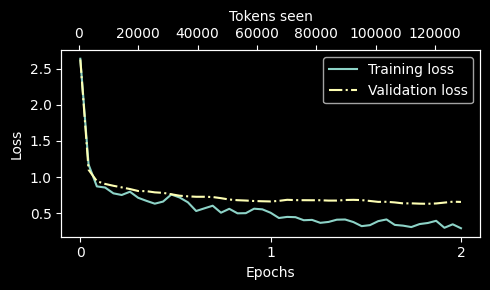

In [36]:
from previous_chapters import plot_losses

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

- 如我们所见，在第一个训练轮次的开始，损失急剧下降，这意味着模型开始迅速学习。
- 大约在训练1个训练轮次时，模型出现了轻微的过拟合。

## 7.7 抽取并保存模型回复

<img src="https://raw.githubusercontent.com/MLNLP-World/LLMs-from-scratch-CN/main/imgs/ch7/17.png" width=500px>

- 在本节中，我们保存测试集的响应，以便在下一节进行评估。
- 我们还保存了模型的副本，以备将来使用。
- 但首先，让我们粗略的查看一下微调后的模型生成的响应。

In [37]:
torch.manual_seed(123)

for entry in test_data[:3]:
    input_text = format_input(entry)
    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
)

    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {response_text.strip()}")
    print("-------------------------------------")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

Correct response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a bullet.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

Correct response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> The type of cloud associated with thunderstorms is a cumulus cloud.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Prejudice'.

Correct response:
>> Jane Austen.

Model response:
>> The author of 'Pride and Prej

- 从测试集中的指令、给定的响应以及模型的响应来看，模型的表现相对较好。
- 第一个和最后一个指令的回答显然是正确的。
- 第二个回答接近正确；模型回答为“积云”（cumulus cloud），而不是“雷雨云”（cumulonimbus）（不过需要注意的是，积云可能发展成雷雨云，而雷雨云具有产生雷暴的能力）。
- 最重要的是，我们可以看到，模型评估结果不像第六章那样直接，因为在第六章中我们只需要计算正确的垃圾邮件/非垃圾邮件类别标签的百分比来获得分类准确率。
- 实际上，指令微调后的LLM（如聊天机器人）通常通过多种方法进行评估：
  - 短答案和多选基准，如MMLU（“大规模多任务语言理解测量”，[https://arxiv.org/abs/2009.03300](https://arxiv.org/abs/2009.03300)），测试模型的知识。
  - 与其他LLM的人工偏好比较，如LMSYS聊天机器人竞技场（[https://arena.lmsys.org](https://arena.lmsys.org)）。
  - 自动化对话基准，其中使用另一个LLM，如GPT-4，来评估响应，例如AlpacaEval（[https://tatsu-lab.github.io/alpaca_eval/](https://tatsu-lab.github.io/alpaca_eval/)）。
- 在下一节中，我们将使用类似AlpacaEval的方法，使用另一个LLM来评估我们模型的响应；不过，我们将使用自己的测试集，而不是公开可用的基准数据集。
- 为此，我们将模型的响应添加到 `test_data` 字典中，并将其保存为 `"instruction-data-with-response.json"` 文件，以便记录，这样我们可以在需要时在单独的Python会话中加载并分析它。

In [38]:
from tqdm import tqdm  # 导入进度条工具 tqdm
# enumerate(test_data)：遍历 test_data 里的每一条指令，同时记录索引 i 和内容 entry    tqdm()：给循环加上进度条，显示总共有多少条、当前处理到第几条
for i, entry in tqdm(enumerate(test_data), total=len(test_data)):
    input_text = format_input(entry)  # 格式化输入指令
    token_ids = generate(             # 调用模型生成回复
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)                               # 把 token 转回文本
    response_text = generated_text[len(input_text):].replace("### Response:", "").strip()  # 提取干净的模型回复文本
    test_data[i]["model_response"] = response_text  # 给 test_data 里的每一条数据，新增一个 model_response 字段，保存模型生成的回复
# 保存结果到 JSON 文件 （保存的是：模型生成的「指令 - 回复」文本数据）
with open("instruction-data-with-response.json", "w") as file:
    json.dump(test_data, file, indent=4)  # json.dump：把修改后的 test_data 写入文件、   indent=4：让 JSON 文件格式化输出，方便后续查看和分析

100%|██████████| 110/110 [03:36<00:00,  1.97s/it]


- 让我们再检查一下其中一个条目，确认回复是否已正确添加到 `test_data` 中。

In [39]:
print(test_data[0])

{'instruction': 'Rewrite the sentence using a simile.', 'input': 'The car is very fast.', 'output': 'The car is as fast as lightning.', 'model_response': 'The car is as fast as a bullet.'}


- 最后保存这个模型以便日后复用

In [40]:
import re

file_name = f"{re.sub(r'[ ()]', '', CHOOSE_MODEL) }-sft.pth"
torch.save(model.state_dict(), file_name)  # 保存的是：模型的权重参数（state_dict）
print(f"Model saved as {file_name}")

# Load model via
# model.load_state_dict(torch.load("gpt2-medium355M-sft.pth"))

Model saved as gpt2-medium355M-sft.pth


## 7.8 评价微调后的大语言模型

<img src="https://raw.githubusercontent.com/MLNLP-World/LLMs-from-scratch-CN/main/imgs/ch7/18.png" width=500px>

- 在本节中，我们通过使用另一个更强大的LLM来自动化微调后的LLM的响应评估。
- 具体来说，我们使用了Meta AI发布的8B参数指令微调Llama 3模型，该模型可以通过ollama本地运行（[https://ollama.com](https://ollama.com)）。
- （另外，如果您更喜欢通过OpenAI API使用像GPT-4这样的更强大的LLM，请参阅 [llm-instruction-eval-openai.ipynb](../03_model-evaluation/llm-instruction-eval-openai.ipynb) ）

- Ollama 是一个高效运行LLM的程序。
- 它是 llama.cpp 的一个封装器（[https://github.com/ggerganov/llama.cpp](https://github.com/ggerganov/llama.cpp)），该项目使用纯C/C++实现LLM，以最大化效率。
- 请注意，Ollama 是用于生成文本（进行模型推理）的工具，而不是用于训练或微调LLM的工具。
- 在运行以下代码之前，请访问 [https://ollama.com](https://ollama.com) 安装Ollama，并按照指示操作（例如，点击“下载”按钮并下载适用于您操作系统的Ollama应用程序）。

- 对于macOS和Windows用户，点击已下载的ollama应用程序；如果提示安装命令行工具，选择“是”。
- Linux用户可以使用ollama网站上提供的安装命令。

- 通常，在我们通过命令行使用ollama之前，需要先启动ollama应用程序或在单独的终端中运行 `ollama serve`。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/ollama-run.webp?1" width=700px>

- 在另一个终端运行ollama应用程序或 `ollama serve` 后，在命令行中执行以下命令，尝试使用8B参数的Llama 3模型（该模型占用4.7GB的存储空间，第一次执行此命令时会自动下载）。
```bash
# 8B 模型
ollama run llama3
```


输出可能如下所示

```
$ ollama run llama3
pulling manifest
pulling 6a0746a1ec1a... 100% ▕████████████████▏ 4.7 GB
pulling 4fa551d4f938... 100% ▕████████████████▏  12 KB
pulling 8ab4849b038c... 100% ▕████████████████▏  254 B
pulling 577073ffcc6c... 100% ▕████████████████▏  110 B
pulling 3f8eb4da87fa... 100% ▕████████████████▏  485 B
verifying sha256 digest
writing manifest
removing any unused layers
success
```

- 请注意，`llama3` 指的是经过指令微调的8B参数Llama 3模型。

- 使用ollama与 `"llama3"` 模型（8B参数模型）时需要16GB的RAM；如果您的机器不支持，可以尝试使用更小的模型，例如3.8B参数的phi-3模型，通过设置 `model = "phi-3"`，该模型只需8GB的RAM。

- 如果您的机器支持，您还可以使用更大的70B参数Llama 3模型，只需将 `llama3` 替换为 `llama3:70b`。

- 下载完成后，您将看到一个命令行提示符，可以与模型进行对话。

- 尝试输入类似 "What do llamas eat?" 的提示，模型应返回类似以下的输出：

```
>>> What do llamas eat?
Llamas are ruminant animals, which means they have a four-chambered
stomach and eat plants that are high in fiber. In the wild, llamas
typically feed on:
1. Grasses: They love to graze on various types of grasses, including tall
grasses, wheat, oats, and barley.
```

- 结束运行仅需要输入 `/bye`

- 以下代码检查ollama会话是否正常运行

In [41]:
import psutil

def check_if_running(process_name):
    running = False
    for proc in psutil.process_iter(["name"]):
        if process_name in proc.info["name"]:
            running = True
            break
    return running

ollama_running = check_if_running("ollama")
# 检查运行情况
if not ollama_running:
    raise RuntimeError("Ollama not running. Launch ollama before proceeding.")
print("Ollama running:", check_if_running("ollama"))

RuntimeError: Ollama not running. Launch ollama before proceeding.

In [ ]:
# 该单元格是可选的；它允许您重新启动notebook
# 并只运行第7.7节，而无需重新运行之前的代码。
import json
from tqdm import tqdm
# 我们的初始数据集
file_path = "instruction-data-with-response.json"

with open(file_path, "r") as file:
    test_data = json.load(file)


def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""

    return instruction_text + input_text

- 现在，与我们之前使用的 `ollama run` 命令互动模型的另一种方式是通过其REST API，在Python中通过以下函数进行操作。
- 在运行notebook中的下一个单元格之前，请确保ollama仍在运行（前面的代码单元格应显示 `"Ollama running: True"`）。
- 接下来，运行以下代码单元格来查询模型。

In [ ]:
import urllib.request

def query_model(
    prompt,
    model="llama3",
    url="http://localhost:11434/api/chat"
):
    # 预处理的类型与符号
    # 创建数据负载字典
    data = {
        "model": model,
        "messages": [
            {"role": "user", "content": prompt}
        ],
        "options": {     # 以下设置是为了获得确定性的响应
            "seed": 123,
            "temperature": 0,
            "num_ctx": 2048
        }
    }
    

    # 将字典转换为JSON格式的字符串并编码为字节
    payload = json.dumps(data).encode("utf-8")
    # 对JSON进行编码
    # 创建请求对象，设置请求方法为POST并添加必要的头部信息
    request = urllib.request.Request(
        url,
        data=payload,
        method="POST"
    )
    # 设置请求头部为JSON格式
    request.add_header("Content-Type", "application/json")

    # 发送请求并捕获响应
    response_data = ""
    with urllib.request.urlopen(request) as response:
        # 读取并解码响应
        while True:
            line = response.readline().decode("utf-8")
            if not line:
                break
            response_json = json.loads(line)
            response_data += response_json["message"]["content"]

    return response_data


model = "llama3"
result = query_model("What do Llamas eat?", model)
print(result)

- 现在，使用我们上面定义的 `query_model` 函数，我们可以评估微调后的模型的响应；让我们在前面一节中查看的前三个测试集响应上试试。

In [ ]:
for entry in test_data[:3]:
    # 自定义提示词
    prompt = (
        f"Given the input `{format_input(entry)}` "
        f"and correct output `{entry['output']}`, "
        f"score the model response `{entry['model_response']}`"
        f" on a scale from 0 to 100, where 100 is the best score. "
    )

    print("\nDataset response:")
    print(">>", entry['output'])
    print("\nModel response:")
    print(">>", entry["model_response"])
    print("\nScore:")
    print(">>", query_model(prompt))
    print("\n-------------------------")

- 如我们所见，Llama 3 模型给出了合理的评估
- 如果模型的回答不完全正确，它会根据部分正确的内容给予相应的分数，例如“积云”这个回答。
- 请注意，之前的提示会返回详细的评估结果；我们可以调整提示，使其生成介于0到100之间的整数分数（其中100为最佳），以便计算模型的平均得分。
- 对测试集中的110个条目进行评估大约需要1分钟(在M3 MacBook Air上运行)。

In [ ]:
# 生成模型得分的函数
def generate_model_scores(json_data, json_key, model="llama3"):
    scores = []
    
    for entry in tqdm(json_data, desc="Scoring entries"):
        prompt = (
            f"Given the input `{format_input(entry)}` "
            f"and correct output `{entry['output']}`, "
            f"score the model response `{entry[json_key]}`"
            f" on a scale from 0 to 100, where 100 is the best score. "
            f"Respond with the integer number only."
        )
        score = query_model(prompt, model)
        try:
            scores.append(int(score))
        except ValueError:
            print(f"Could not convert score: {score}")
            continue

    return scores


scores = generate_model_scores(test_data, "model_response")
print(f"Number of scores: {len(scores)} of {len(test_data)}")
print(f"Average score: {sum(scores)/len(scores):.2f}\n")

- 我们的模型平均得分超过50分，可以将其作为参考，与其他模型进行对比;或尝试其他训练设置来改进模型表现。
- 截至汉化的时候,ollama 在不同操作系统上的结果可能会有所不同，因此您得到的数值可能与上面显示的略有差异。

- 以下看作参考
  - Llama 3 8B 基础模型得分为 58.51
  - Llama 3 8B 指令微调模型得分为 82.65

## 7.9 总结

### 7.9.1 展望

- 本章标志着本书的结束。
- 我们覆盖了LLM开发的主要步骤：实现LLM架构、预训练LLM以及微调模型。

<img src="https://raw.githubusercontent.com/MLNLP-World/LLMs-from-scratch-CN/main/imgs/ch7/19.png" width=500px>

- 正如本章所述,指令微调后，有时会进行一个可选步骤——偏好微调.
- 偏好微调有助于定制模型，更好地符合用户偏好。如果您感兴趣，可以查看 [../04_preference-tuning-with-dpo](../04_preference-tuning-with-dpo) 文件夹。

- 本GitHub仓库还包含大量额外的附加资料，您可能会喜欢；有关更多信息，请查看本仓库README页面中的 [Bonus Material](https://github.com/rasbt/LLMs-from-scratch?tab=readme-ov-file#bonus-material) 部分。

### 7.9.2 紧跟时代潮流

- 本节没有代码内容。

### 7.9.3 寄语

- 我希望您喜欢这个从零实现LLM的过程，以及编写预训练和微调代码的过程。
- 在我看来，从零构建大模型是理解LLM如何工作的最佳方式；我希望您通过这种方式获得了更深入的理解。
- 虽然本书是为了教学目的，但您可能有兴趣将不同的、更强大的LLM应用于实际应用中。
  - 为此，您可以考虑使用一些流行工具，如axolotl（[https://github.com/OpenAccess-AI-Collective/axolotl](https://github.com/OpenAccess-AI-Collective/axolotl)）或LitGPT（[https://github.com/Lightning-AI/litgpt](https://github.com/Lightning-AI/litgpt)），这是我参与开发的工具。

## 总结与收获

- 请参阅 [./gpt_instruction_finetuning.py](./gpt_instruction_finetuning.py) 脚本，它是一个自包含的分类微调脚本。
- [./ollama_evaluate.py](./ollama_evaluate.py) 是基于第7.8节的独立脚本，通过Ollama和Llama 3评估包含“output”和“response”键的JSON文件。
- [./load-finetuned-model.ipynb](./load-finetuned-model.ipynb) 笔记本演示了如何在新会话中加载微调后的模型。
- 您可以在 [./exercise-solutions.ipynb](./exercise-solutions.ipynb) 找到习题解答。

## 接下来做什么？

- 恭喜您完成了本书！如果您在寻找更多资源，我在这个GitHub仓库中添加了几个附加部分，您可能会感兴趣。
- 附加资料的完整列表可以在主README的 [Bonus Material](https://github.com/rasbt/LLMs-from-scratch?tab=readme-ov-file#bonus-material) 部分查看。
- 在这里，我想特别强调几个我喜欢的部分：
  1. [从零开始的直接偏好优化（DPO）用于LLM对齐](../04_preference-tuning-with-dpo/dpo-from-scratch.ipynb) 实现了一种流行的偏好调优机制，使本章的模型与人类偏好更加契合。
  2. [从零开始实现Llama 3.2](../../ch05/07_gpt_to_llama/standalone-llama32.ipynb)，这是Meta AI流行的Llama 3.2的从零实现，包括加载官方的预训练权重；如果您想做一些额外的实验，可以将每章中的 `GPTModel` 模型替换为 `Llama3Model` 类（它可以作为1:1替代）。
  3. [将GPT转换为Llama](../../ch05/07_gpt_to_llama) 包含逐步指南的代码，解释了GPT-2和各种Llama模型之间的区别。
  4. [理解嵌入层和线性层的区别](../../ch02/03_bonus_embedding-vs-matmul/embeddings-and-linear-layers.ipynb) 是一个概念性解释，说明了我们在LLM输入阶段使用的PyTorch中的 `Embedding` 层在数学上等价于对独热编码数据应用的线性层。
- 祝您学习愉快！